# LDV Spectral & Mode Analysis

Companion notebook to [LDV_Cable_Coupling_v2.ipynb](LDV_Cable_Coupling_v2.ipynb).
Shares the in-memory dataset cache in [`ldv_analysis/io.py`](ldv_analysis/io.py)
so loads are free if the v2 notebook already ran in this kernel.

| § | Content |
|---|---|
| 0 | Imports & dataset selection |
| 1 | Raw traces on a uniform amplitude scale |
| 2 | Amplitude spectra |
| 3 | Interactive dataset / sensor / component browser |
| 4 | Cable-free shaker reference — `DIRECT_SHAKER_REF_*.mat` |
| 5 | Placeholder: future analyses (mode analysis, cross-cable comparison, ...) |


---
## § 0  Imports & dataset selection


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, signal, geometry, plotting, widgets

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.0,
})

# Small subset by default - edit to change.
ACTIVE_LABELS = [
    "Cable3_5cm",
    "Cable3_10cm",
    "Cable3_15cm_Sag",
    "Cable3_15cm",
   # "Cable7_15cm_Sag",
]
DATASETS = config.select_datasets(ACTIVE_LABELS)

for cfg in DATASETS:
    io.load_cable_dataset(cfg)
    print(f"  {cfg['label']:25s}  n_sensors={cfg['n_sensors']:2d}  fs={cfg['fs']:.0f} Hz  duration={cfg['t'][-1]:.2f} s")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  [Cable3_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  Cable3_5cm                 n_sensors= 9  fs=5000 Hz  duration=12.00 s
  [Cable3_10cm] shaker active channel: idx=17 (of 18 channels; 1 non-zero)
  Cable3_10cm                n_sensors=17  fs=5000 Hz  duration=12.00 s
  [Cable3_15cm_Sag] shaker active channel: idx=17 (of 18 channels; 1 non-zero)
  Cable3_15cm_Sag            n_sensors=17  fs=5000 Hz  duration=12.00 s
  Cable3_15cm                n_sensors=17  fs=5000 Hz  duration=12.00 s


---
## § 1  Raw traces (uniform amplitude scale)

Same y-limit across all subplots so the dominant component jumps out.
`share_scale='dataset'` → one y-limit per dataset.
`share_scale='component'` → one y-limit per column (relative comparison within a component).


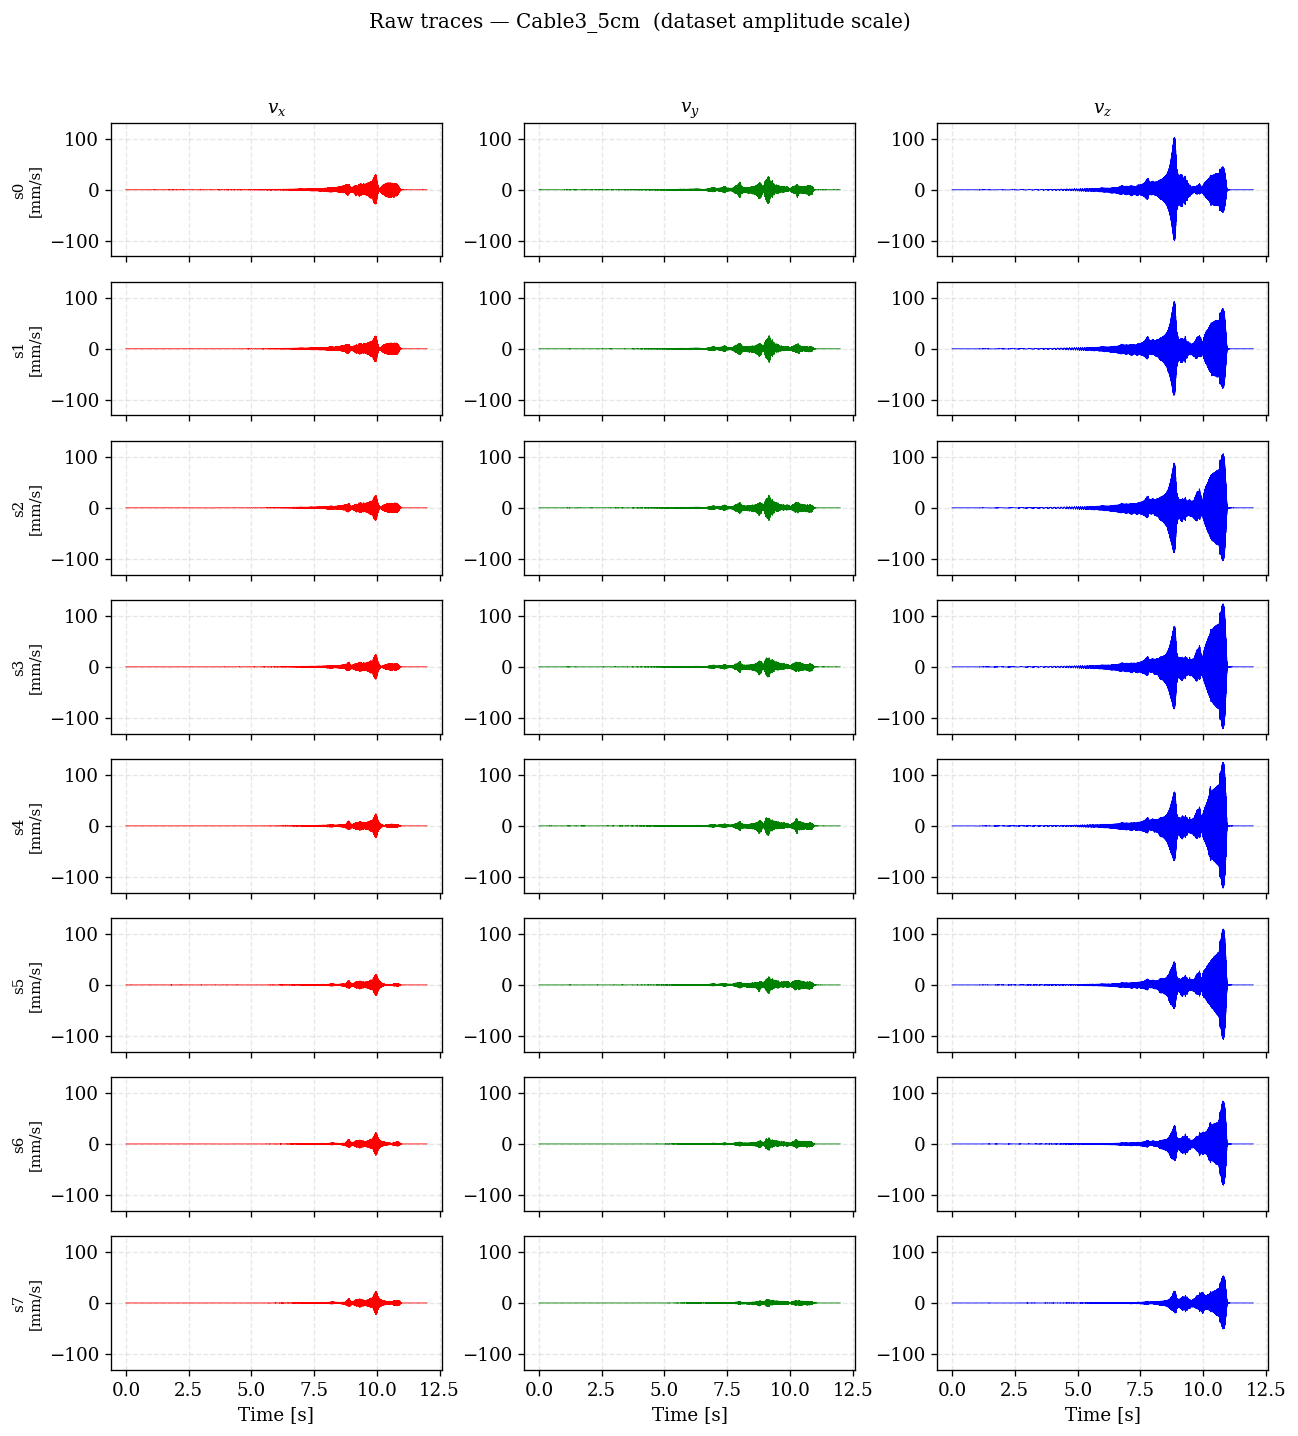

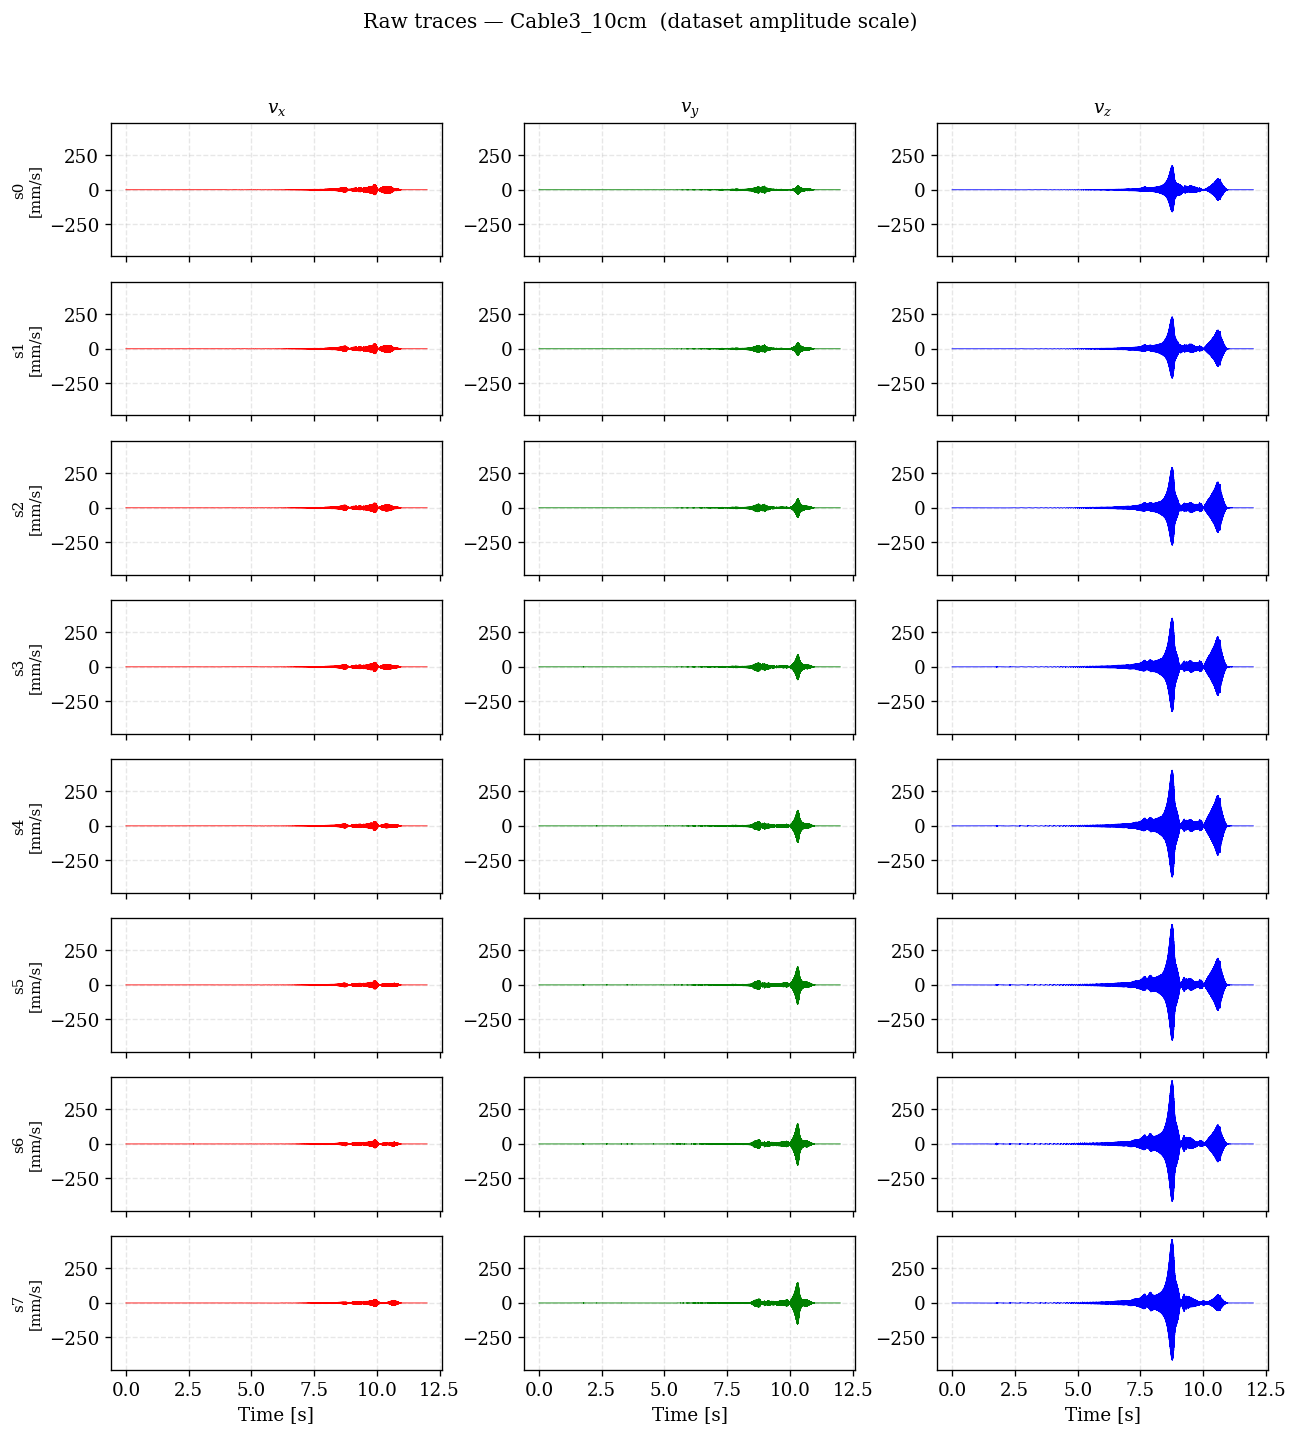

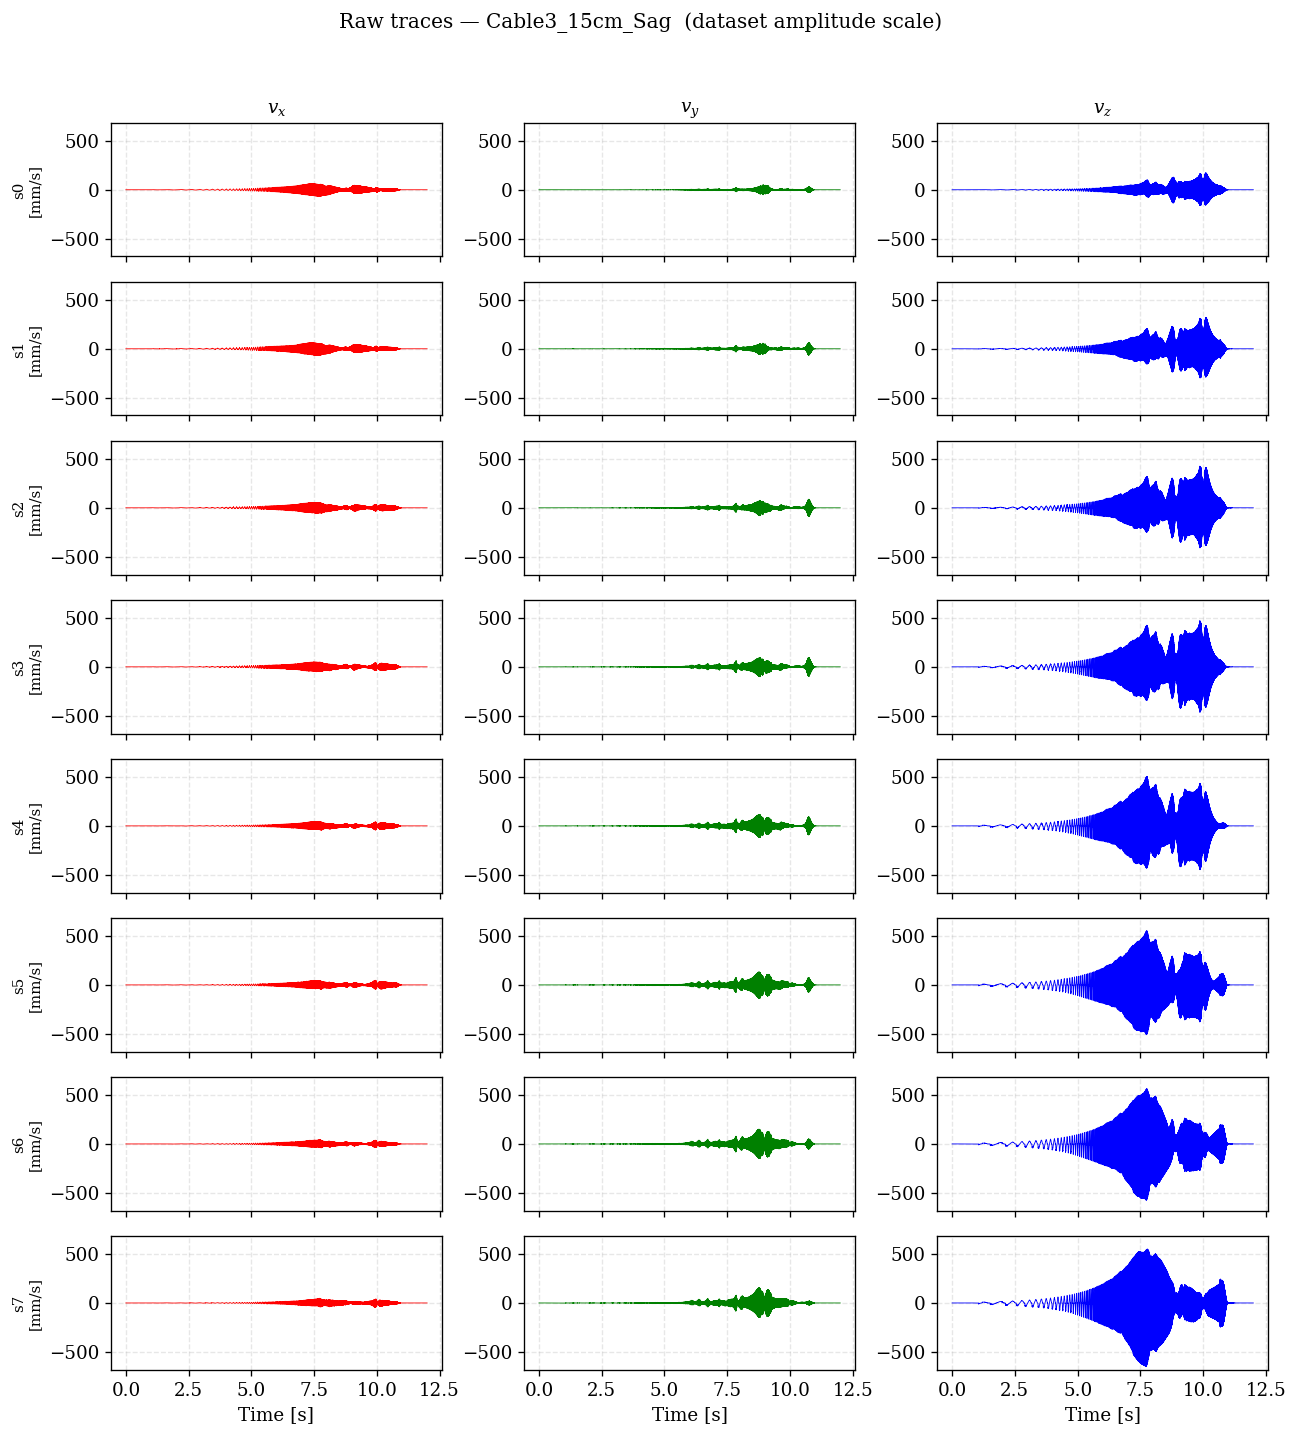

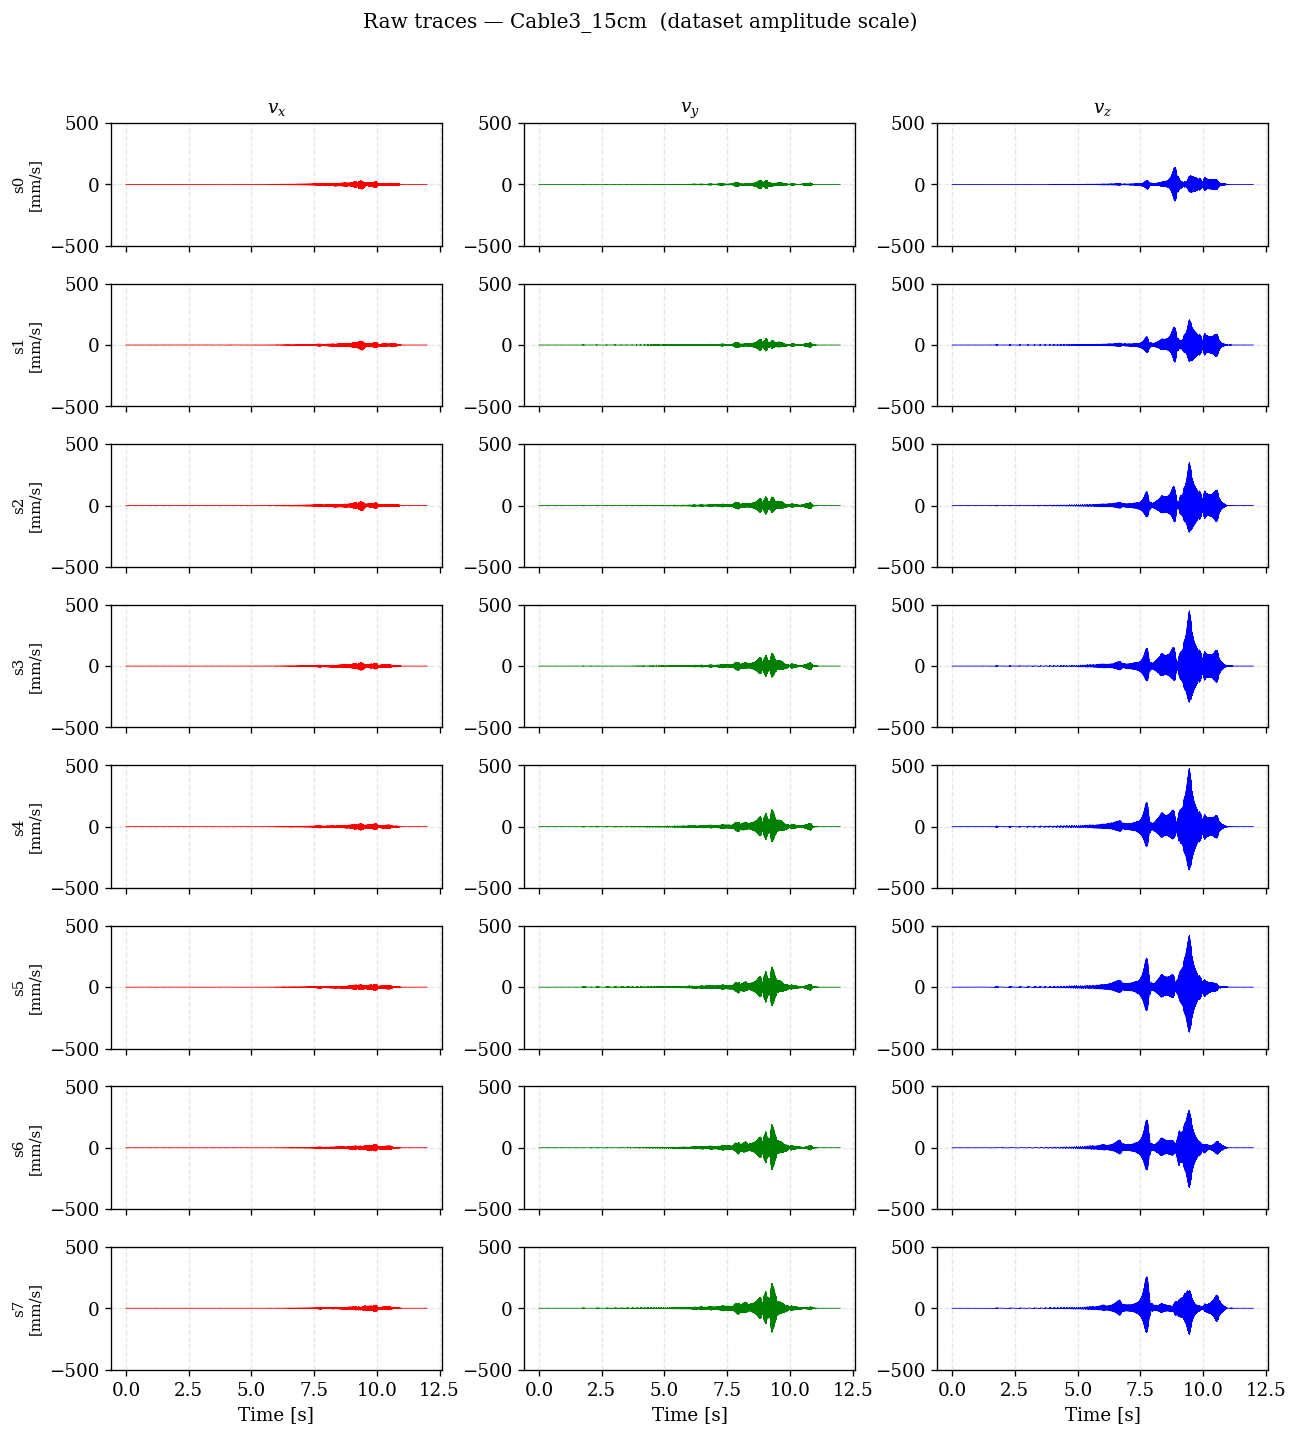

In [19]:
for cfg in DATASETS:
    plotting.plot_raw_traces_uniform(
        cfg, components=('vx', 'vy', 'vz'),
        share_scale='dataset',          # try 'component' for per-axis scaling
        max_rows=8,                     # cap rows so the grid stays readable
    )


---
## § 2  Amplitude spectra

`overlay_sensors=True`: one panel per component, all sensors overlaid faint,
mean across sensors in bold. Switch to a sensor-grid view by setting it False.


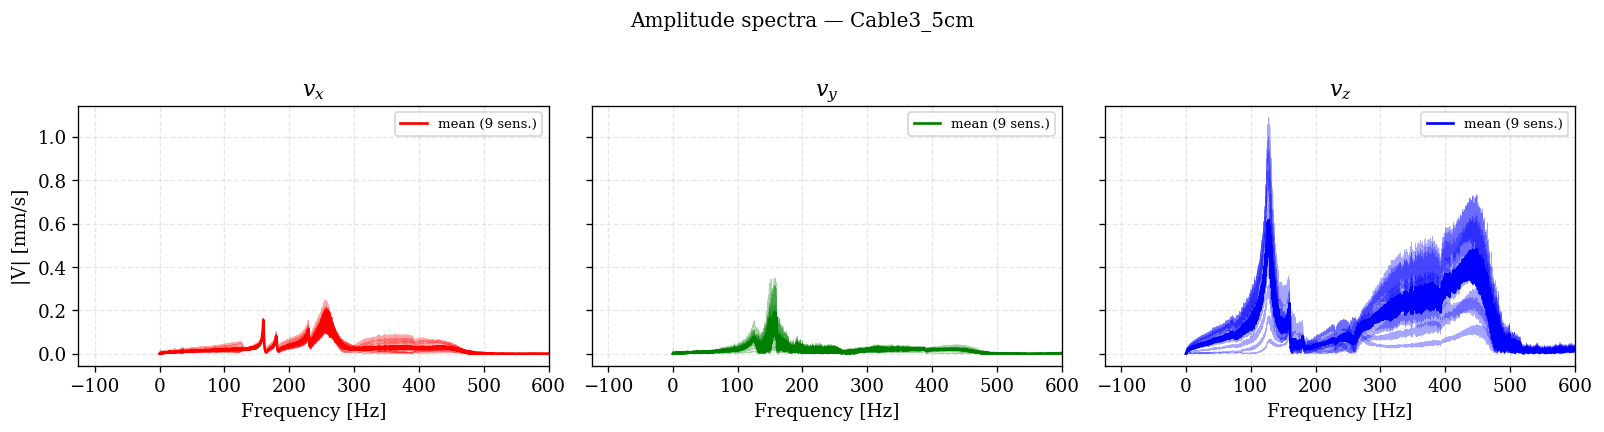

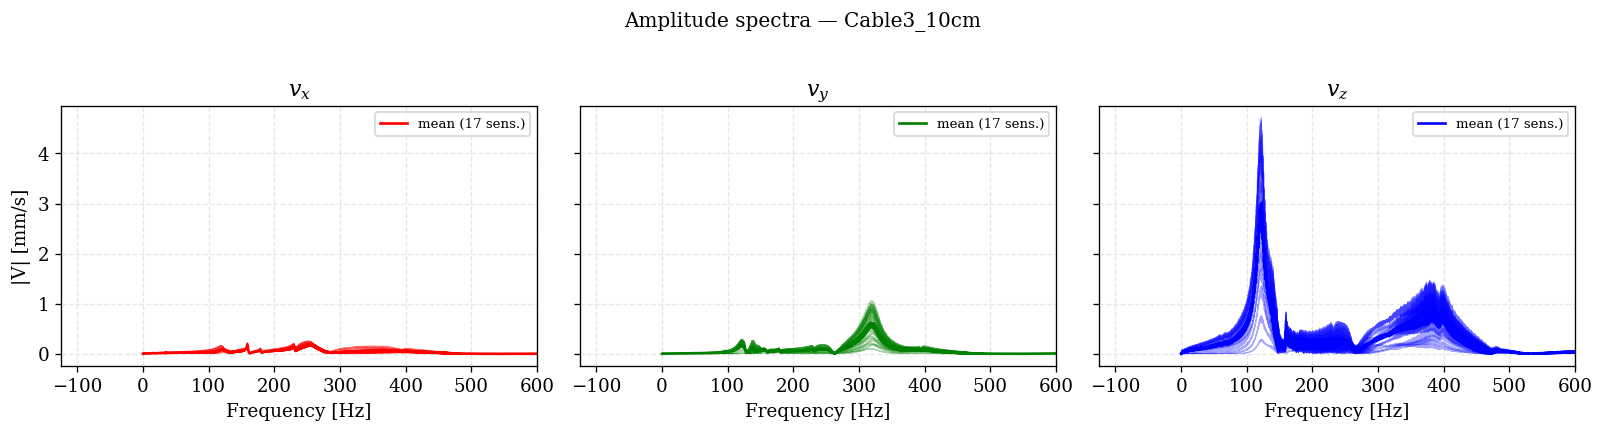

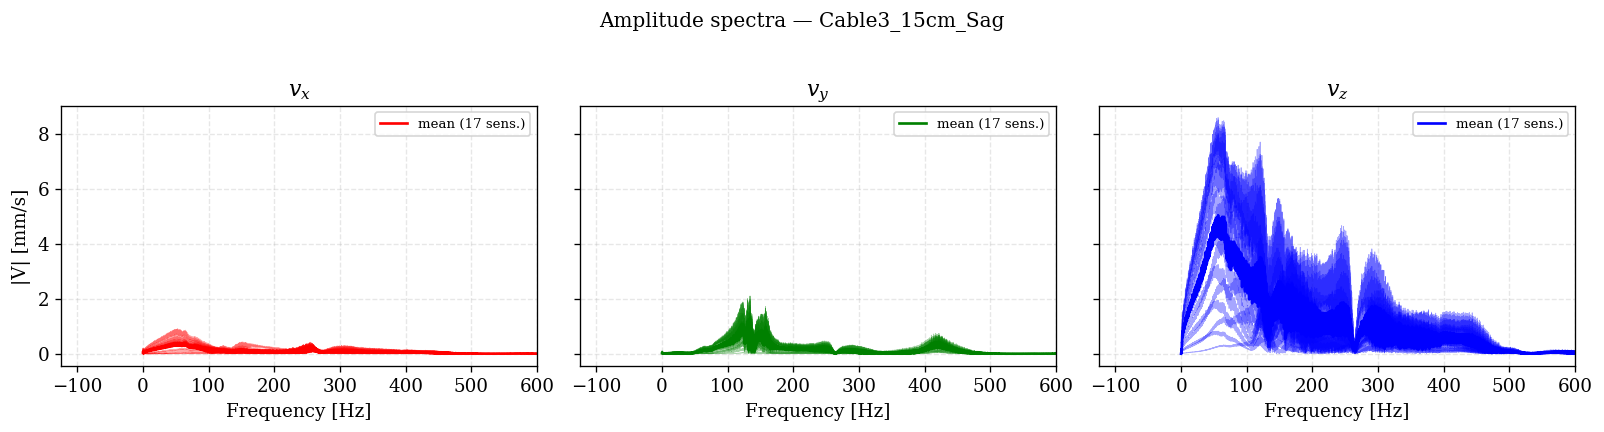

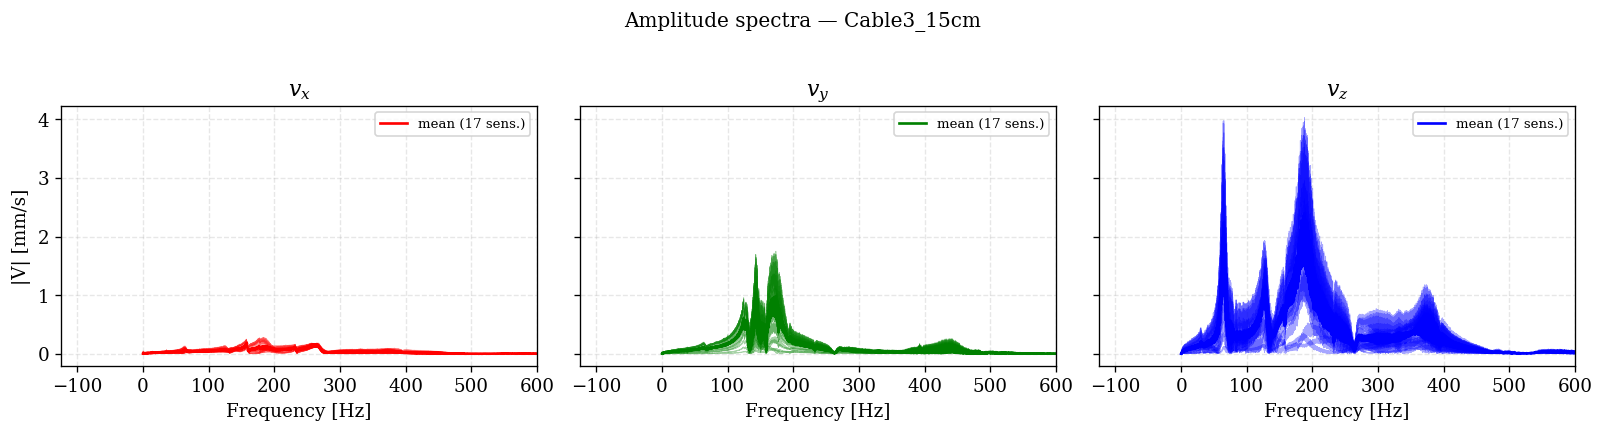

In [20]:
for cfg in DATASETS:
    plotting.plot_amplitude_spectra(
        cfg, components=('vx', 'vy', 'vz'),
        f_max=600.0, xscale='linear', yscale='linear', # log or linear
        overlay_sensors=True,
    )


---
## § 2.1  Dominant spectral peaks

For each dataset the **mean spectrum** across all sensors is computed
per component and the top 4 dominant frequencies in 0–500 Hz are
identified. Cable sensors below (cable LDV) and shaker channels
(`sh_vx/y/z`, single point at shaker attachment) are shown separately.

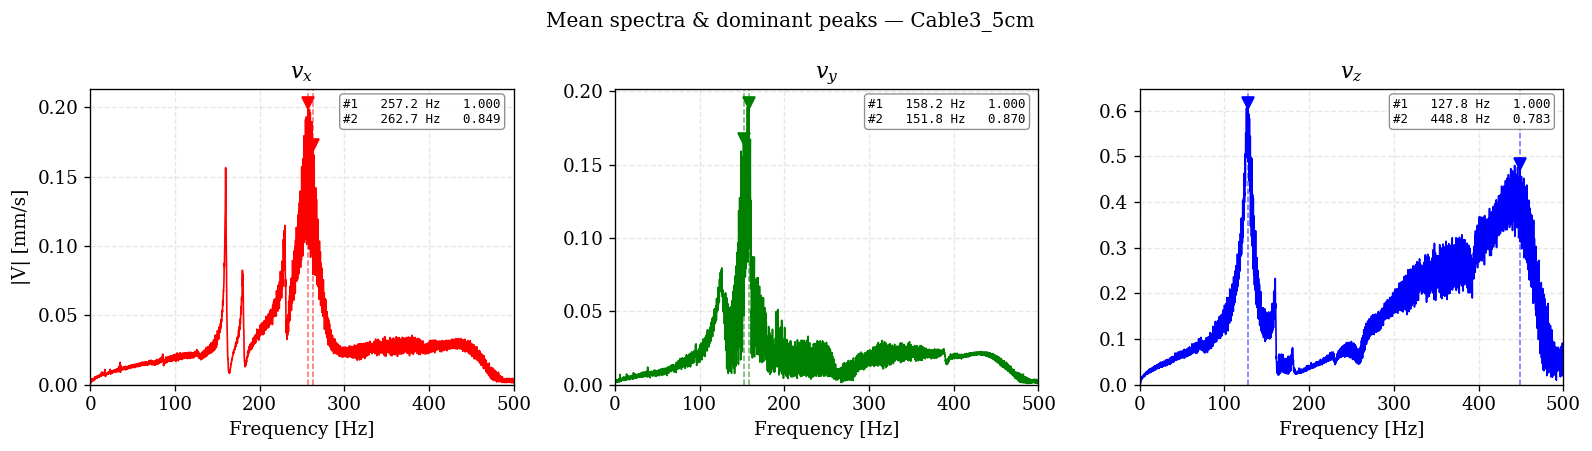

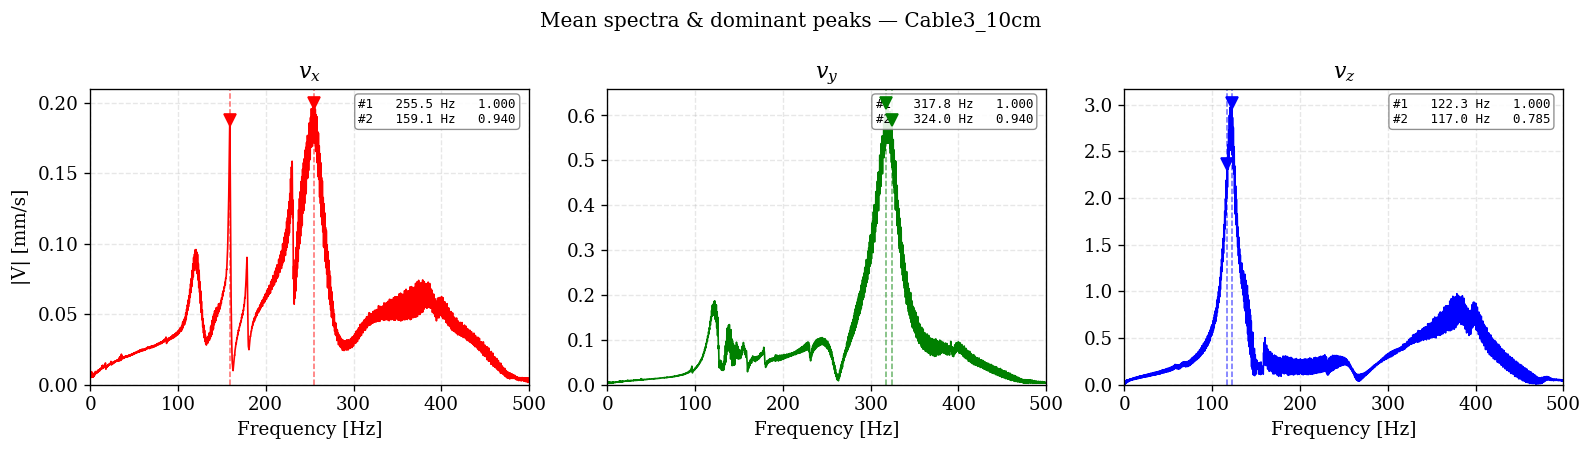

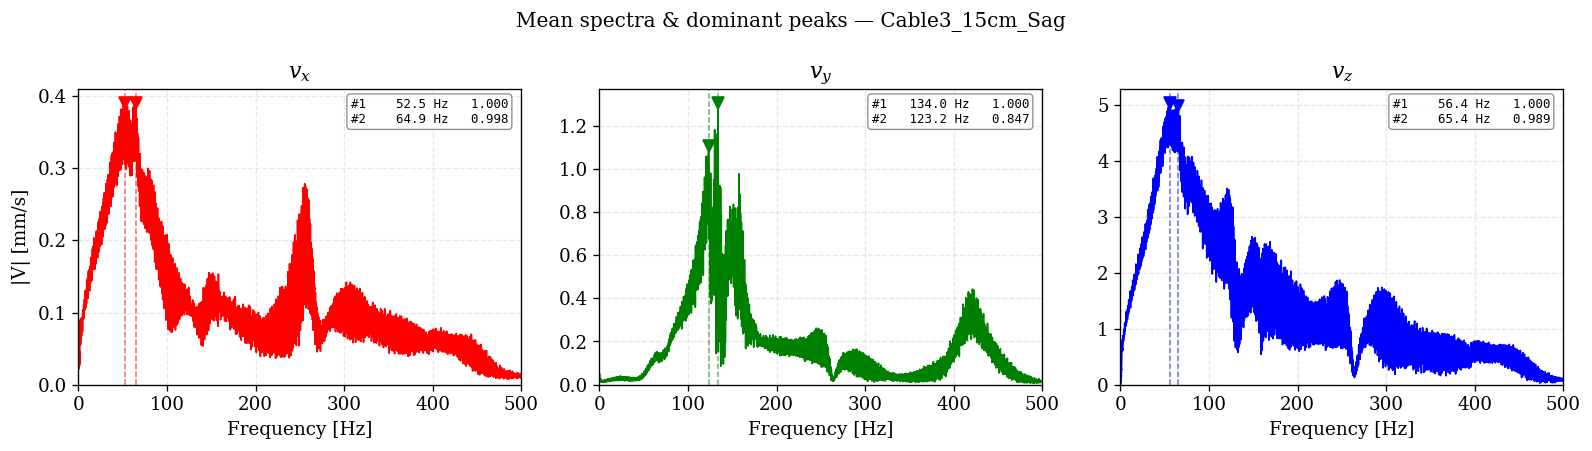

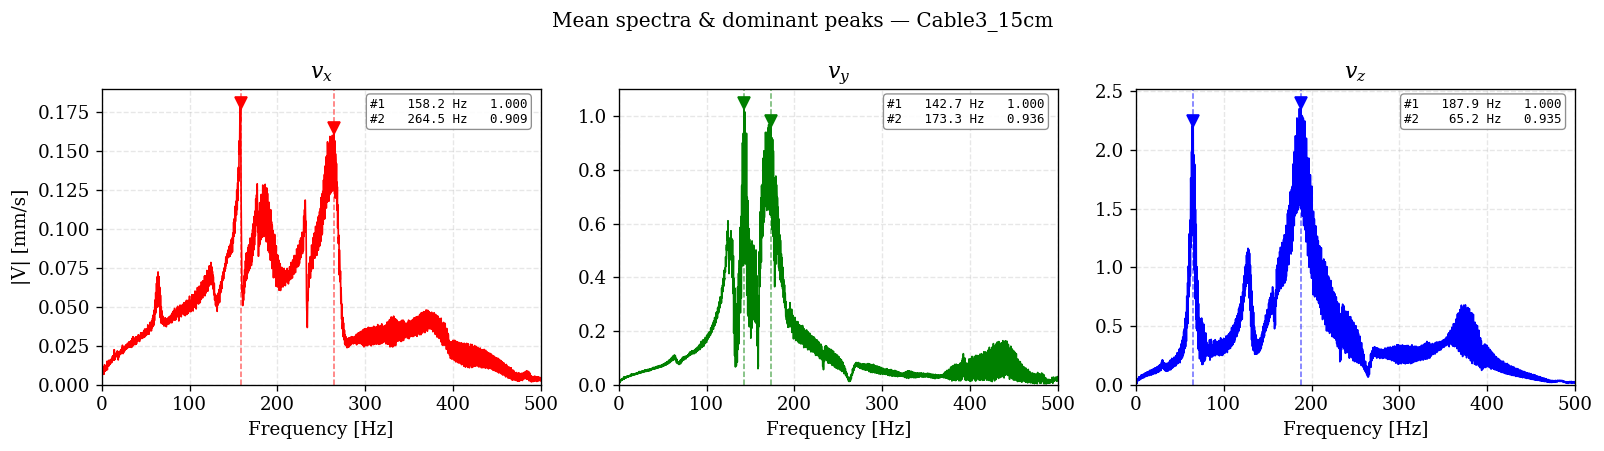

In [21]:
# Cable LDV: mean spectrum + top 4 peaks, one figure per dataset
for cfg in DATASETS:
    plotting.plot_spectral_peak_overview(
        cfg, components=('vx', 'vy', 'vz'),
        f_max=500.0, n_peaks=2,
        xscale='linear', yscale='linear',
    )

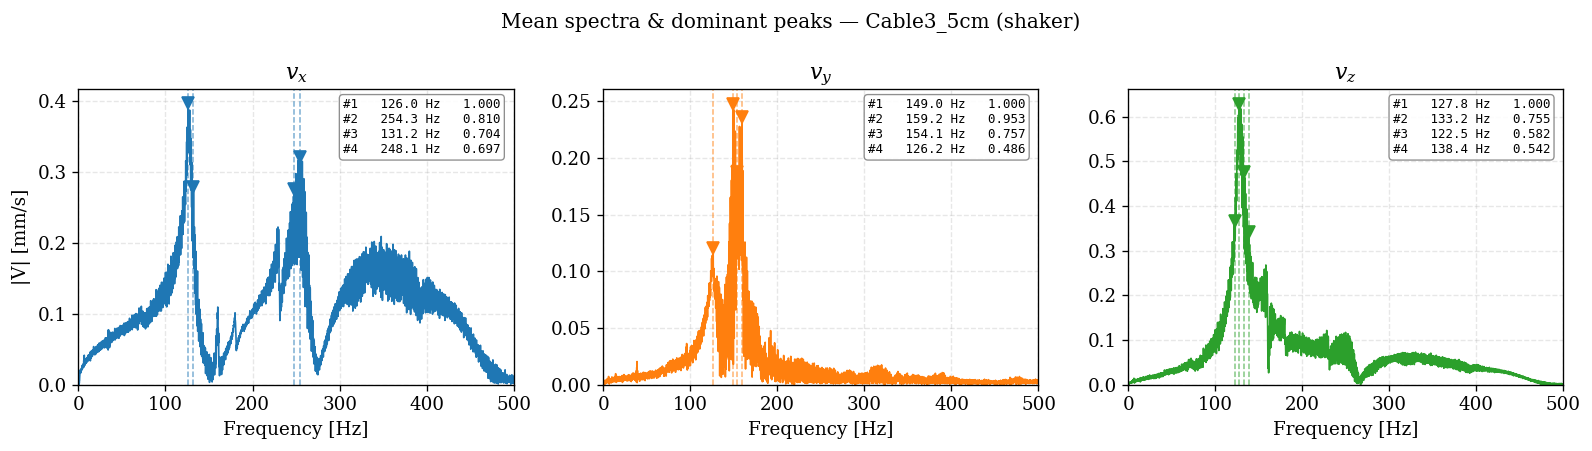

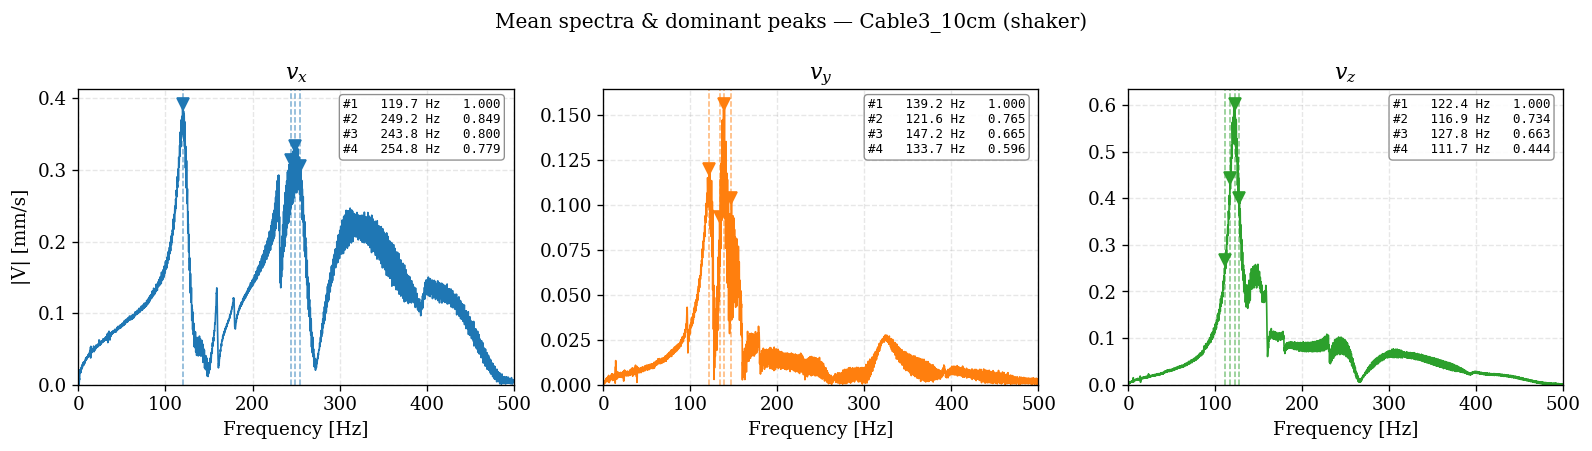

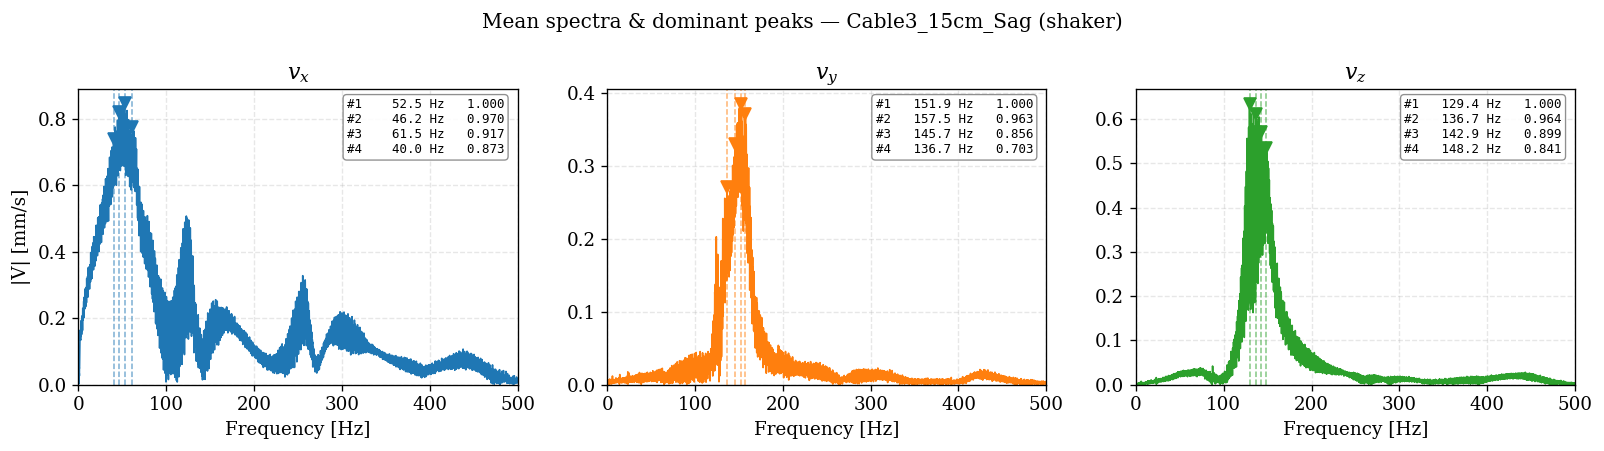

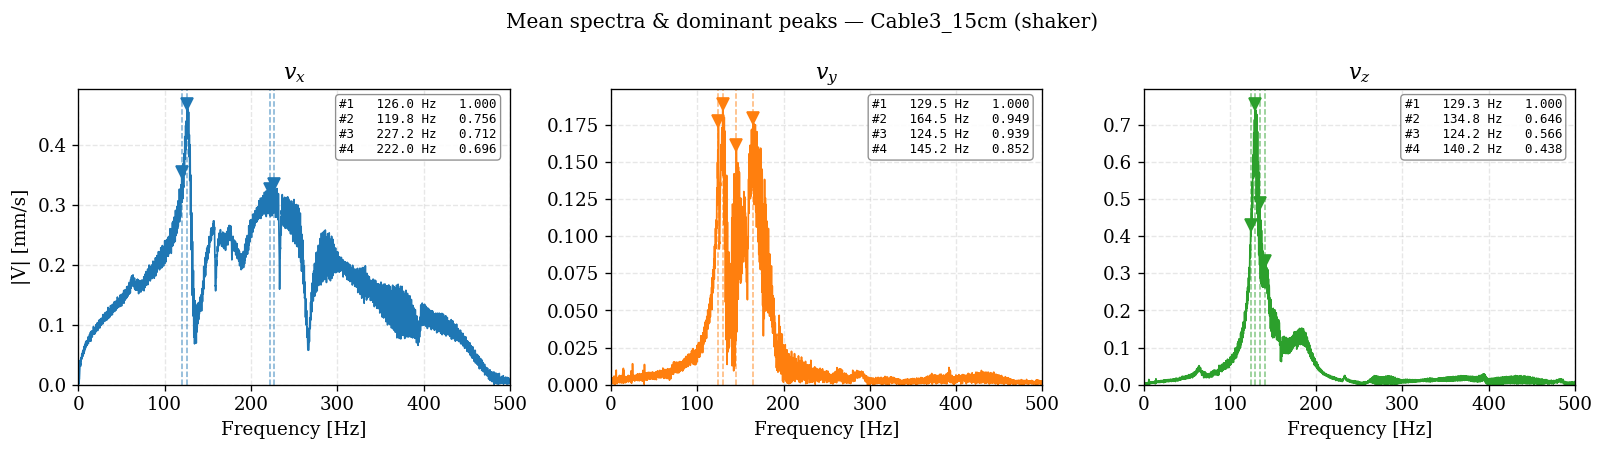

In [22]:
# Shaker channels: same analysis using sh_vx / sh_vy / sh_vz
for cfg in DATASETS:
    plotting.plot_spectral_peak_overview(
        cfg, components=('sh_vx', 'sh_vy', 'sh_vz'),
        f_max=500.0, n_peaks=4,
        xscale='linear', yscale='linear',
    )

---
## § 2.2  Peak summary table

Wide-form table: one row per (dataset, component), columns for each
peak rank (frequency [Hz] and normalised amplitude).

In [23]:
# Cable LDV peak table
plotting.spectral_peak_table(
    DATASETS, components=('vx', 'vy', 'vz'),
    f_max=500.0, n_peaks=4,
)


Dominant spectral peaks (top 4, 0–500 Hz)


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,Cable3_5cm,vx,257.200000,1.0000,262.700000,0.8493,251.600000,0.8025,160.000000,0.7699
1,Cable3_5cm,vy,158.200000,1.0000,151.800000,0.8704,146.100000,0.6171,164.500000,0.4531
2,Cable3_5cm,vz,127.800000,1.0000,448.800000,0.7830,442.500000,0.7779,435.200000,0.7455
3,Cable3_10cm,vx,255.500000,1.0000,159.100000,0.9403,250.200000,0.9294,260.900000,0.8474
4,Cable3_10cm,vy,317.800000,1.0000,324.000000,0.9400,312.200000,0.8563,330.200000,0.7070
5,Cable3_10cm,vz,122.300000,1.0000,117.000000,0.7846,127.700000,0.6582,111.700000,0.4823
6,Cable3_15cm_Sag,vx,52.500000,1.0000,64.900000,0.9982,46.200000,0.9508,58.700000,0.9381
7,Cable3_15cm_Sag,vy,134.000000,1.0000,123.200000,0.8474,157.500000,0.7481,117.000000,0.6850
8,Cable3_15cm_Sag,vz,56.400000,1.0000,65.400000,0.9888,50.700000,0.9446,45.200000,0.8668
9,Cable3_15cm,vx,158.200000,1.0000,264.500000,0.9089,257.200000,0.8614,177.100000,0.7124


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,Cable3_5cm,vx,257.2,1.0,262.7,0.8493,251.6,0.8025,160.0,0.7699
1,Cable3_5cm,vy,158.2,1.0,151.8,0.8704,146.1,0.6171,164.5,0.4531
2,Cable3_5cm,vz,127.8,1.0,448.8,0.7830,442.5,0.7779,435.2,0.7455
3,Cable3_10cm,vx,255.5,1.0,159.1,0.9403,250.2,0.9294,260.9,0.8474
4,Cable3_10cm,vy,317.8,1.0,324.0,0.9400,312.2,0.8563,330.2,0.7070
5,Cable3_10cm,vz,122.3,1.0,117.0,0.7846,127.7,0.6582,111.7,0.4823
6,Cable3_15cm_Sag,vx,52.5,1.0,64.9,0.9982,46.2,0.9508,58.7,0.9381
7,Cable3_15cm_Sag,vy,134.0,1.0,123.2,0.8474,157.5,0.7481,117.0,0.6850
8,Cable3_15cm_Sag,vz,56.4,1.0,65.4,0.9888,50.7,0.9446,45.2,0.8668
9,Cable3_15cm,vx,158.2,1.0,264.5,0.9089,257.2,0.8614,177.1,0.7124


In [24]:
# Shaker-channel peak table
plotting.spectral_peak_table(
    DATASETS, components=('sh_vx', 'sh_vy', 'sh_vz'),
    f_max=500.0, n_peaks=4,
)


Dominant spectral peaks (top 4, 0–500 Hz)


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,Cable3_5cm (shaker),vx,126.000000,1.0000,254.300000,0.8098,131.200000,0.7036,248.100000,0.6967
1,Cable3_5cm (shaker),vy,149.000000,1.0000,159.200000,0.9533,154.100000,0.7571,126.200000,0.4863
2,Cable3_5cm (shaker),vz,127.800000,1.0000,133.200000,0.7551,122.500000,0.5824,138.400000,0.5417
3,Cable3_10cm (shaker),vx,119.700000,1.0000,249.200000,0.8488,243.800000,0.8002,254.800000,0.7787
4,Cable3_10cm (shaker),vy,139.200000,1.0000,121.600000,0.7654,147.200000,0.6645,133.700000,0.5962
5,Cable3_10cm (shaker),vz,122.400000,1.0000,116.900000,0.7342,127.800000,0.6630,111.700000,0.4444
6,Cable3_15cm_Sag (shaker),vx,52.500000,1.0000,46.200000,0.9696,61.500000,0.9170,40.000000,0.8727
7,Cable3_15cm_Sag (shaker),vy,151.900000,1.0000,157.500000,0.9626,145.700000,0.8565,136.700000,0.7025
8,Cable3_15cm_Sag (shaker),vz,129.400000,1.0000,136.700000,0.9636,142.900000,0.8993,148.200000,0.8408
9,Cable3_15cm (shaker),vx,126.000000,1.0000,119.800000,0.7563,227.200000,0.7122,222.000000,0.6958


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,Cable3_5cm (shaker),vx,126.0,1.0,254.3,0.8098,131.2,0.7036,248.1,0.6967
1,Cable3_5cm (shaker),vy,149.0,1.0,159.2,0.9533,154.1,0.7571,126.2,0.4863
2,Cable3_5cm (shaker),vz,127.8,1.0,133.2,0.7551,122.5,0.5824,138.4,0.5417
3,Cable3_10cm (shaker),vx,119.7,1.0,249.2,0.8488,243.8,0.8002,254.8,0.7787
4,Cable3_10cm (shaker),vy,139.2,1.0,121.6,0.7654,147.2,0.6645,133.7,0.5962
5,Cable3_10cm (shaker),vz,122.4,1.0,116.9,0.7342,127.8,0.6630,111.7,0.4444
6,Cable3_15cm_Sag (shaker),vx,52.5,1.0,46.2,0.9696,61.5,0.9170,40.0,0.8727
7,Cable3_15cm_Sag (shaker),vy,151.9,1.0,157.5,0.9626,145.7,0.8565,136.7,0.7025
8,Cable3_15cm_Sag (shaker),vz,129.4,1.0,136.7,0.9636,142.9,0.8993,148.2,0.8408
9,Cable3_15cm (shaker),vx,126.0,1.0,119.8,0.7563,227.2,0.7122,222.0,0.6958


---
## § 3  Interactive dataset / component / sensor browser

- Dataset dropdown: pick which of the loaded cfgs to view.
- Component dropdown: vx / vy / vz.
- Sensor slider: 0 → n_sensors-1.
- View: `time` (raw trace) or `spectrum` (single-sided FFT).


In [25]:
widgets.dataset_sensor_browser(DATASETS, components=('vx', 'vy', 'vz'))


---
## § 3.1  Cable spectrograms

Same `plot_spectrogram_grid` as the shaker reference further down, but for
cable LDV traces. Each cable dataset is `(N_t, N_sensors)` per component, so
you must pick a sensor with `sensor_index`. For interactive exploration across
datasets and sensors, see the spectrogram browser further below.


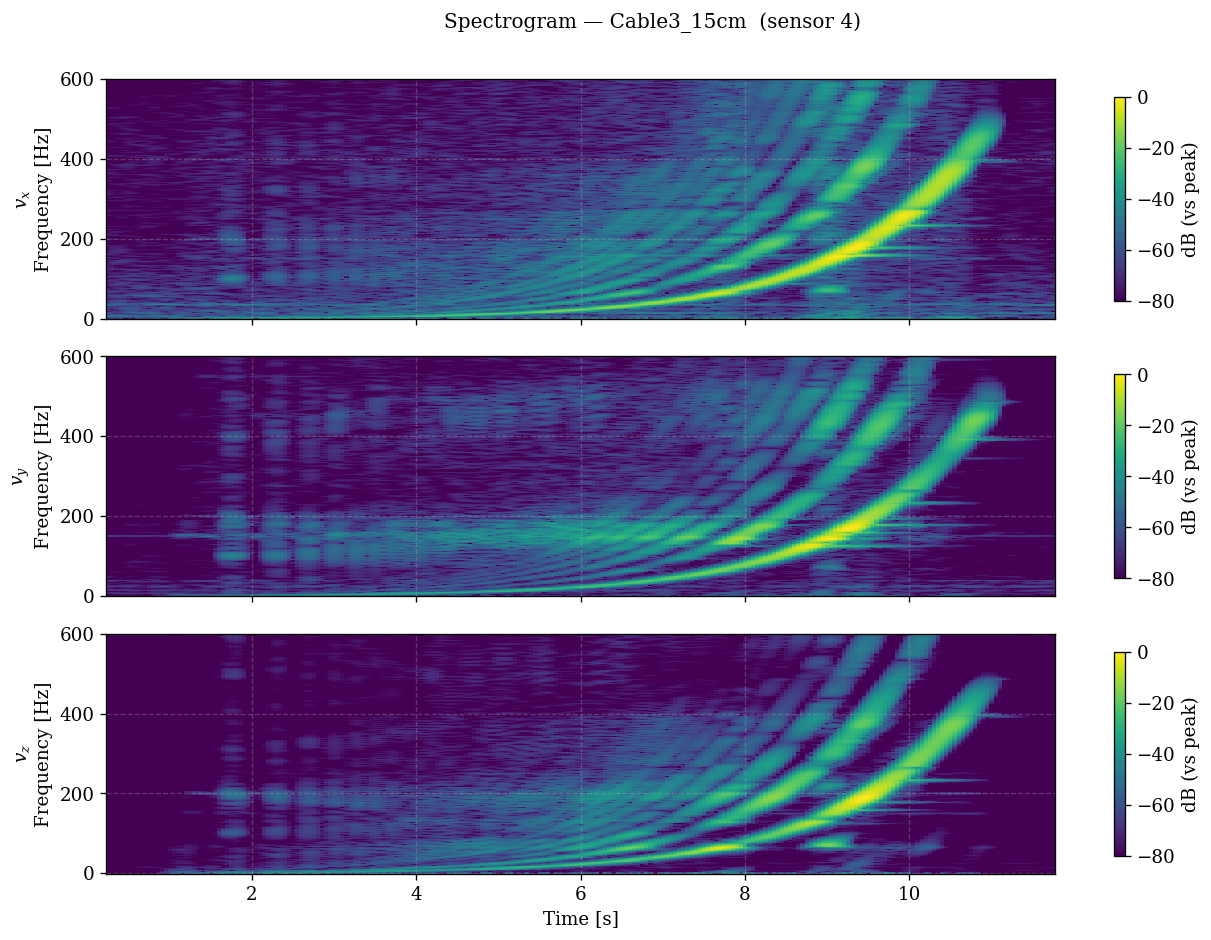

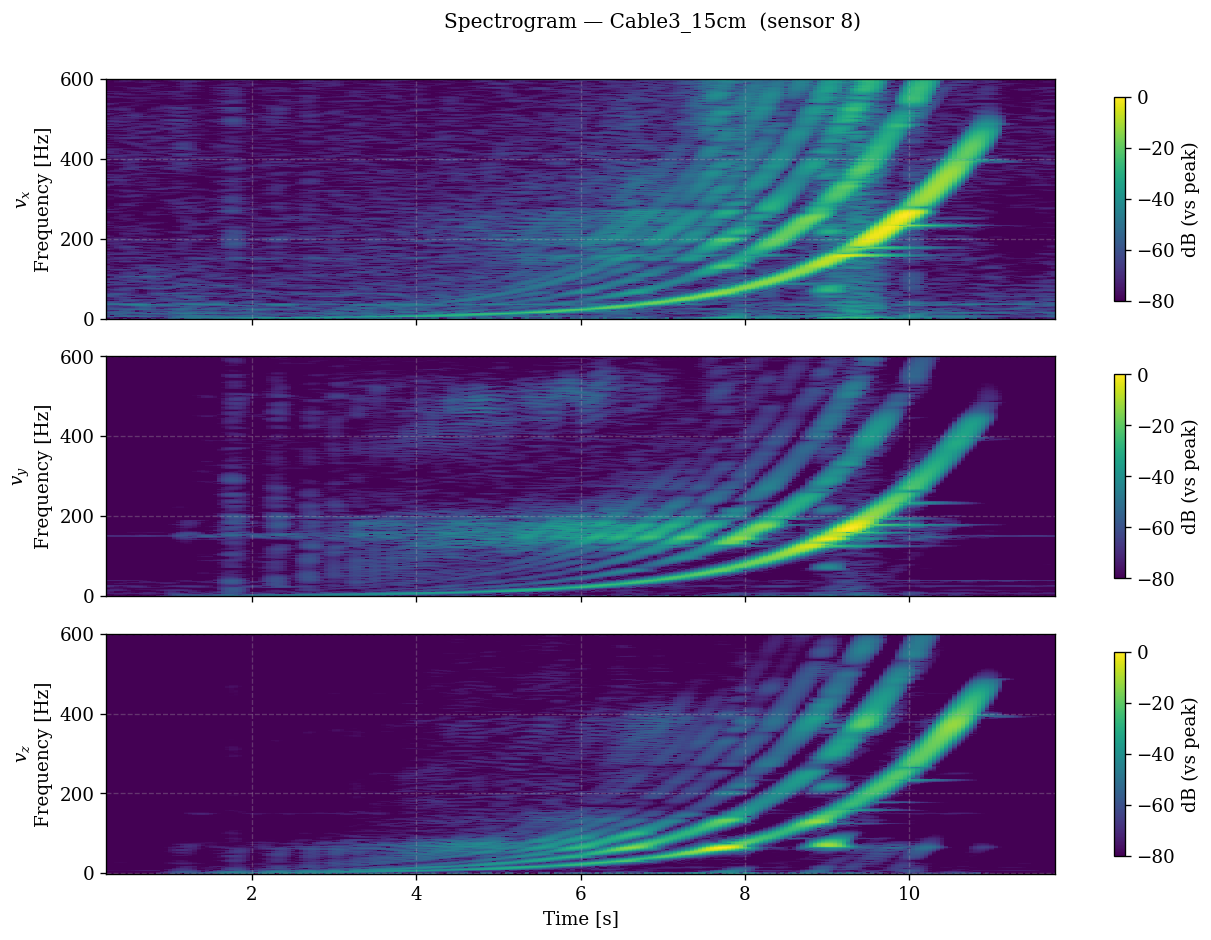

In [9]:
# Spectrograms of cable datasets.
# Cable arrays are 2-D (N_t, N_sensors); `sensor_index` picks one LDV point.
# Loop over a handful of sensor indices to see how the spectral content varies
# along the cable.
SENSORS_TO_SHOW = (4, 8) # (0,2,4)   # extend / change as needed

for cfg in DATASETS:
    for s_idx in SENSORS_TO_SHOW:
        if s_idx >= cfg['n_sensors']:
            continue
        plotting.plot_spectrogram_grid(
            cfg, components=('vx', 'vy', 'vz'),
            sensor_index=s_idx,
            nperseg=int(cfg['fs'] // 2),      # ~2 Hz frequency resolution
            f_max=600.0,
            db_floor=-80,
        )


---
## § 3.2  Interactive spectrogram browser

Pick any loaded source (cable cfgs or shaker references), pick a sensor,
adjust `f_max`, `nperseg`, and the dB floor on the fly. The sensor slider
auto-disables for 1-D sources like a shaker reference.

Build the source list however you like — e.g. mix `DATASETS` with the
`DIRECT_SHAKER_REF` reference loaded further down:

```python
widgets.spectrogram_browser(DATASETS + [direct])
```


In [10]:
widgets.spectrogram_browser(DATASETS)


---
## § 4  Cable-free shaker reference

The file `DIRECT_SHAKER_REF_avg5_05V_R2_fs5kHz_60000nt_LogSweep_1_500Hz_12_5s_500mms_m2.mat`
records the bare shaker performing the same 1–500 Hz / 10 s log-sweep with **no cable
attached** — pure shaker response. Useful for normalising cable-loaded measurements.

We do three things:
1. Raw traces on a shared amplitude scale.
2. Amplitude spectra of all three components.
3. Spectrograms (one panel per component) — the sweep should appear as a curved
   ridge from ~1 Hz to ~500 Hz over the 10 s window.


In [11]:
direct = io.load_shaker_reference(config.DIRECT_SHAKER_REF)
print(f"fs = {direct['fs']:.0f} Hz   n_samples = {direct['n_samples']}   "
      f"duration = {direct['t'][-1]:.2f} s")
print(f"peak |v|:  x={np.abs(direct['vx']).max()*1e3:.2f}  "
      f"y={np.abs(direct['vy']).max()*1e3:.2f}  "
      f"z={np.abs(direct['vz']).max()*1e3:.2f}  [mm/s]")


  [C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Data\DIRECT_SHAKER_REF_avg5_05V_R2_fs5kHz_60000nt_LogSweep_1_500Hz_12_5s_500mms_m2.mat] shaker active channel idx=0 (of 1 channels; 1 non-zero)  fs=5000 Hz
fs = 5000 Hz   n_samples = 60000   duration = 12.00 s
peak |v|:  x=59.70  y=10.40  z=14.98  [mm/s]


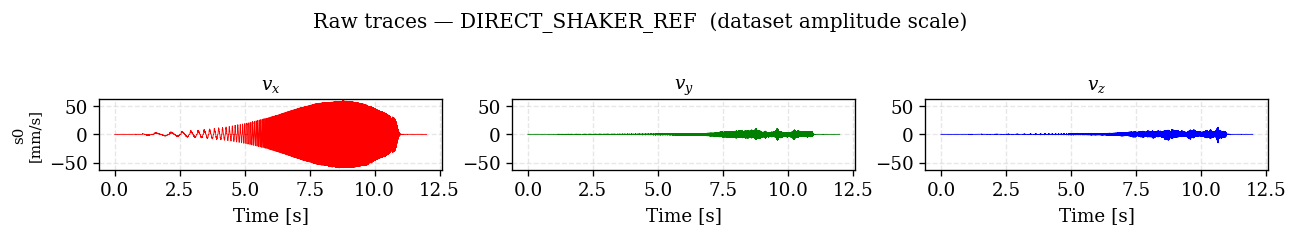

In [12]:
# plot the velocity traces of the shaker reference
plotting.plot_raw_traces_uniform(
    direct, components=('vx', 'vy', 'vz'),
    share_scale='dataset',
    title='DIRECT_SHAKER_REF',
)

# plot the displacement traces of the shaker reference
# plotting.plot_raw_traces_uniform(
#     direct, components=('ux', 'uy', 'uz'),
#     share_scale='dataset',
#     title='DIRECT_SHAKER_REF',
# )

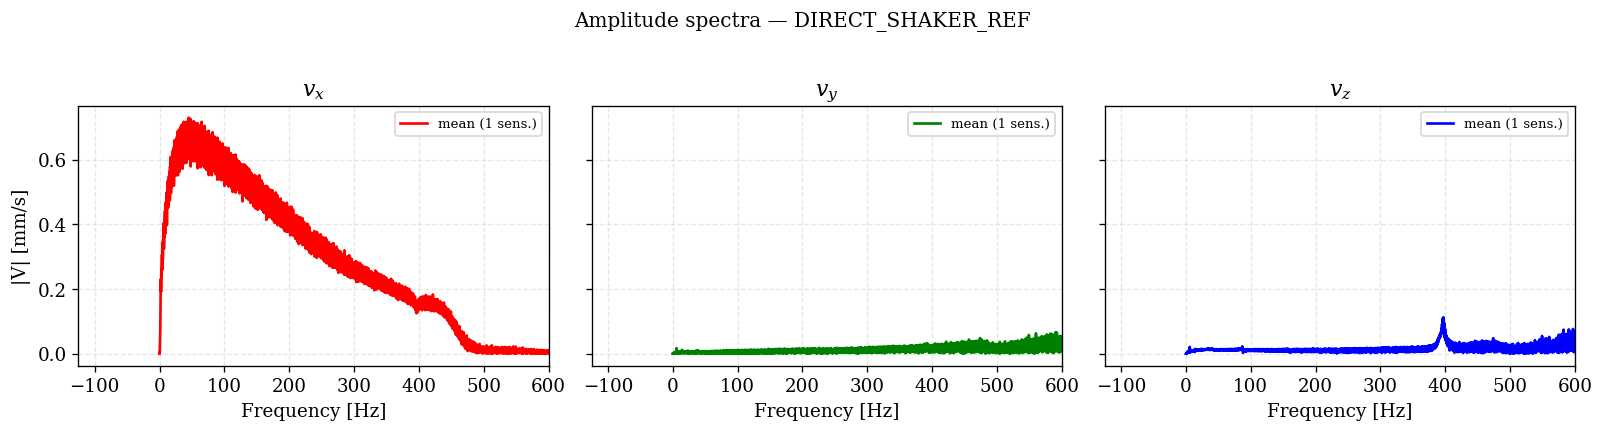

In [13]:
plotting.plot_amplitude_spectra(
    direct, components=('vx', 'vy', 'vz'),
    f_max=600.0, xscale='linear', yscale='linear',
    overlay_sensors=True,
    title='DIRECT_SHAKER_REF',
)


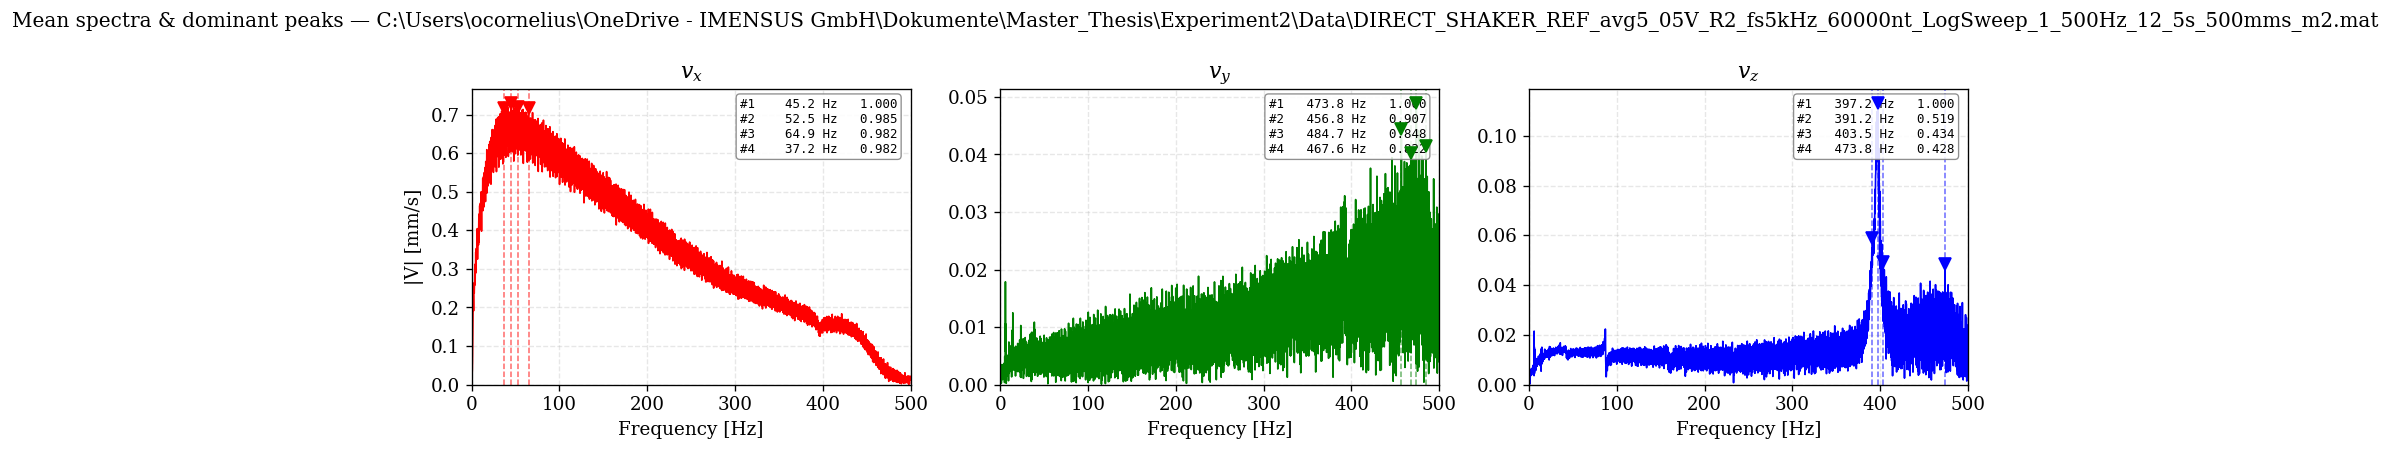

In [14]:
# Direct shaker reference: spectral peak overview
plotting.plot_spectral_peak_overview(
    direct, components=('vx', 'vy', 'vz'),
    f_max=500.0, n_peaks=4,
    xscale='linear', yscale='linear',
    unit_label='|V| [mm/s]',
)

In [15]:
# Direct shaker reference: peak summary table
plotting.spectral_peak_table(
    direct, components=('vx', 'vy', 'vz'),
    f_max=500.0, n_peaks=4,
)


Dominant spectral peaks (top 4, 0–500 Hz)


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Data\DIRECT_SHAKER_REF_avg5_05V_R2_fs5kHz_60000nt_LogSweep_1_500Hz_12_5s_500mms_m2.mat,vx,45.200000,1.0000,52.500000,0.9854,64.900000,0.9823,37.200000,0.9822
1,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Data\DIRECT_SHAKER_REF_avg5_05V_R2_fs5kHz_60000nt_LogSweep_1_500Hz_12_5s_500mms_m2.mat,vy,473.800000,1.0000,456.800000,0.9067,484.700000,0.8482,467.600000,0.8216
2,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Data\DIRECT_SHAKER_REF_avg5_05V_R2_fs5kHz_60000nt_LogSweep_1_500Hz_12_5s_500mms_m2.mat,vz,397.200000,1.0000,391.200000,0.5194,403.500000,0.4341,473.800000,0.4283


,Dataset,Component,Peak1_Hz,Peak1_Amp,Peak2_Hz,Peak2_Amp,Peak3_Hz,Peak3_Amp,Peak4_Hz,Peak4_Amp
0,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Do...,vx,45.2,1.0,52.5,0.9854,64.9,0.9823,37.2,0.9822
1,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Do...,vy,473.8,1.0,456.8,0.9067,484.7,0.8482,467.6,0.8216
2,C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Do...,vz,397.2,1.0,391.2,0.5194,403.5,0.4341,473.8,0.4283


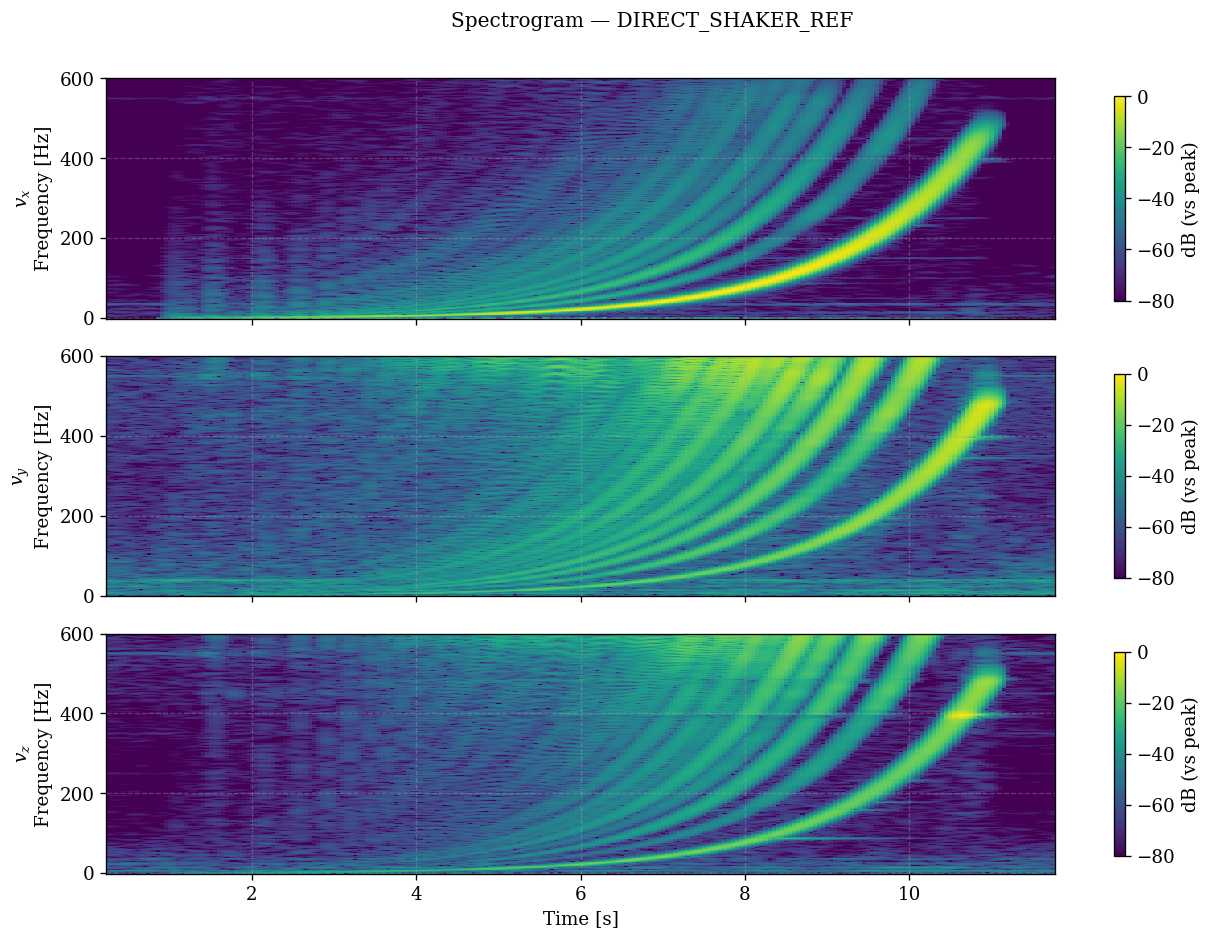

In [16]:
plotting.plot_spectrogram_grid(
    direct, components=('vx', 'vy', 'vz'),
    nperseg=int(direct['fs'] // 2),      # ~2 Hz frequency resolution
    f_max=600.0,
    db_floor=-80,
    title='DIRECT_SHAKER_REF',
)


---
## § 5  Future analyses (placeholders)

Drop new sections here as the investigation expands:

- **Mode analysis** — extract the dominant mode shapes per resonance peak.
- **Cross-cable spectral comparison** — overlay η(f) or spectral coherence across cables.
- **Coherence shaker → cable** — Welch-based magnitude-squared coherence.
- **Damping estimates** — half-power bandwidth around identified resonances.

All of these can reuse the helpers in [`ldv_analysis/`](ldv_analysis); add new
functions to the relevant submodule rather than inline here.
